In [33]:
import pandas as pd

In [34]:
df = pd.read_csv('dataset_v8_cleaned.csv')

In [35]:
df.columns

Index(['dataset', 'id', 'file_number', 'case', 'with companion', 'case type',
       'case status', 'initial_type', 'current_type', 'status', 'date_loss',
       'date_report', 'date_open', 'closed_loss', 'mediation', 'lawsuit',
       'state', 'county', 'court', 'claimant_lf', 'claimant_attorney',
       'claimant_gender', 'claimant_birth', 'claimant_occupation',
       'claimant_income', 'defendant_name', 'defendant_type', 'defendant_lf',
       'defendant_attorney', 'defendant_gender', 'defendant_birth', 'practice',
       'specialty_medmal', 'specialty_ophth', 'nb_defendant',
       'support_defendant_expert', 'location_raw', 'location',
       'procedure_medmal', 'procedure_ophth', 'claimant_negligence',
       'allegation_medmal', 'allegation_ophth', 'wrongful_death',
       'injury_reported', 'severity', 'permanency', 'treatment_needed',
       'claimant_demand_extracted', 'indemnity_reserve',
       'indemnity_reserve_extracted', 'indemnity_paid',
       'indemnity_paid_extract

In [36]:
df = df[['date_open','closed_loss','state','county','defendant_lf']]
df.shape

(1170, 5)

In [37]:
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()} null values")

date_open: 0 null values
closed_loss: 0 null values
state: 0 null values
county: 33 null values
defendant_lf: 568 null values


In [38]:
df=df[df['defendant_lf'].notna()]

In [39]:
#df['claim_length'] = pd.to_datetime(df['claim_length'], format='%m/%d/%Y', errors='coerce')
df['closed_loss'] = pd.to_datetime(df['closed_loss'], format='%m/%d/%Y', errors='coerce')
df['date_open'] = pd.to_datetime(df['date_open'], format='%m/%d/%Y', errors='coerce')

In [40]:
df['claim_length'] = (df['closed_loss'] - df['date_open']).dt.days

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 602 entries, 0 to 1163
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date_open     602 non-null    datetime64[ns]
 1   closed_loss   602 non-null    datetime64[ns]
 2   state         602 non-null    object        
 3   county        577 non-null    object        
 4   defendant_lf  602 non-null    object        
 5   claim_length  602 non-null    int64         
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 32.9+ KB


In [42]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda col: col.str.strip())

In [43]:
df['state'].value_counts()

state
Pennsylvania     530
New York          61
West Virginia     11
Name: count, dtype: int64

In [50]:
selected_state = 'New York'

state_df = df[df['state'] == selected_state][['defendant_lf']].dropna()

In [51]:
state_df.value_counts()

defendant_lf                                               
Adam  Cooper                                                   9
Maguire Cardona, P.C.                                          9
Ricotta, Mattrey, Callocchia, Markel & CassertAttorneys & C    9
O'Connor O'Connor Bresee & First, P.C                          6
Kevin  Ricotta                                                 6
Karen  Butler                                                  5
Thorn Gershon Tymann and Bonanni, LLP                          4
Paul  Jureller                                                 3
Napierski Vandenburg Napierski                                 2
Edward  Laird                                                  2
Jeff  Hurd                                                     2
Heidell Pittoni Murphy & Bach, LLP                             1
Smith Sovik Kendrick & Sugnet, P.C.                            1
Terence  O'Connor                                              1
Tomas  Callocchia             

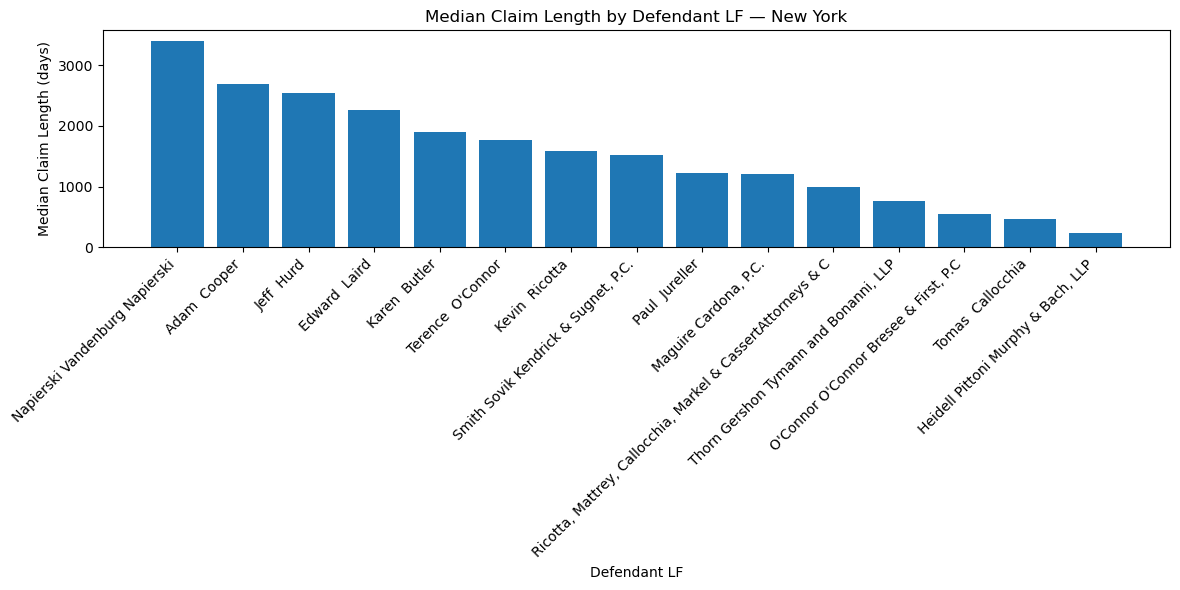

In [52]:
import matplotlib.pyplot as plt
selected_state = 'New York'
result = (
    df[df['state'] == selected_state]
    .groupby('defendant_lf')['claim_length']
    .median()
    .reset_index()
    .rename(columns={'claim_length': 'median_claim_length'})
    .sort_values('median_claim_length', ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(result['defendant_lf'], result['median_claim_length'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Defendant LF')
plt.ylabel('Median Claim Length (days)')
plt.title(f'Median Claim Length by Defendant LF — {selected_state}')
plt.tight_layout()
plt.show()